# **Bayes Classifier (Generative Approach)**

## Dataset Loading

In [18]:
from datasets.iris import load_iris
from datasets.breast_cancer import load_breast_cancer

def load_dataset(name):
    if name == "iris":
        return load_iris()
    elif name == "breast_cancer":
        return load_breast_cancer()
    else:
        raise ValueError(f"Dataset '{name}' not found.")

In [19]:
data = load_dataset("breast_cancer") 

data_norm = data.normalize()
train, test = data_norm.train_test_split(test_size=0.2, random_state=42)

x_train, y_train = train.X, train.y
x_test, y_test = test.X, test.y

Dataset: iris
Task: classification
Samples: 569
Features: 30
Feature names: ['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2', 'smoothness2', 'compactness2', 'concavity2', 'concave_points2', 'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3', 'symmetry3', 'fractal_dimension3']
Target available: Yes
Target name: ['Diagnosis']
Class distribution:
  B: 357
  M: 212


## Naive Bayes Classifier

### Estimate Prior

In [20]:
import numpy as np

In [22]:
class NaiveBayesClassifier:

    def __init__(self, method: str):

        self.method_selection = ["naive", "kde"]
    
        self.method = method            # [naive, kde]
        if method not in self.method_selection:
            raise ValueError(
                f"Invalid method '{method}'. Supported methods are: {self.method_selection}."
            )

    def fit(self, X, y, k=3):
        y = np.asarray(y).ravel()
        if self.method == "naive":
            self.fit_naive(X, y)
        elif self.method == "kde":
            self.fit_kde(X, y, k)

        self._print_fit()

    def fit_naive(self, X, y):

        self.classes, self.n_classes = np.unique(y, return_counts=True)
        # estimating priors
        self.priors = self.n_classes / np.sum(self.n_classes)
        
        # estimating class-conditional likelihoods using Gaussian approach
        self.gaussians = {}
        # minimal standard deviation to prevent division by zero
        eps = 1e-9
        for cls in self.classes:
            X_cls = X[y == cls]
            self.gaussians[cls] = {}
            for i in range(X.shape[1]):
                feature = X_cls[:, i]
                mean = float(np.mean(feature))
                std = float(np.std(feature))
                std = max(std, eps)
                self.gaussians[cls][i] = (mean, std)

    def fit_kde(self, X, y, k):
        raise NotImplementedError()
    
    def predict(self, X):
        # use log version of prior and likelihood to prevent numerical underflow
        predictions = []
        for sample in X:
            posteriors = []
            for idx, cls in enumerate(self.classes):
                # log of prior
                prior = np.log(self.priors[idx])
                likelihood = 0.0
                for i, feature in enumerate(sample):
                    mean, std = self.gaussians[cls][i]
                    # log version of gaussian
                    likelihood += -0.5 * np.log(2 * np.pi * std**2) - ((feature - mean)**2) / (2 * std**2)
                posterior = prior + likelihood
                posteriors.append(posterior)
            predictions.append(self.classes[int(np.argmax(posteriors))])
        return np.array(predictions)
    
    def _print_fit(self):
        print(f"Number of classes: {len(self.n_classes)}")
        print(f"Classes: {self.classes}")
        print(f"Class distribution: {self.n_classes}")
        print("-" * 30)
        print(f"Class priors: {self.priors}")

#### Naive Bayes

In [23]:
model = NaiveBayesClassifier(method="naive")
model.fit(x_train, y_train)

Number of classes: 2
Classes: ['B' 'M']
Class distribution: [285 170]
------------------------------
Class priors: [0.62637363 0.37362637]


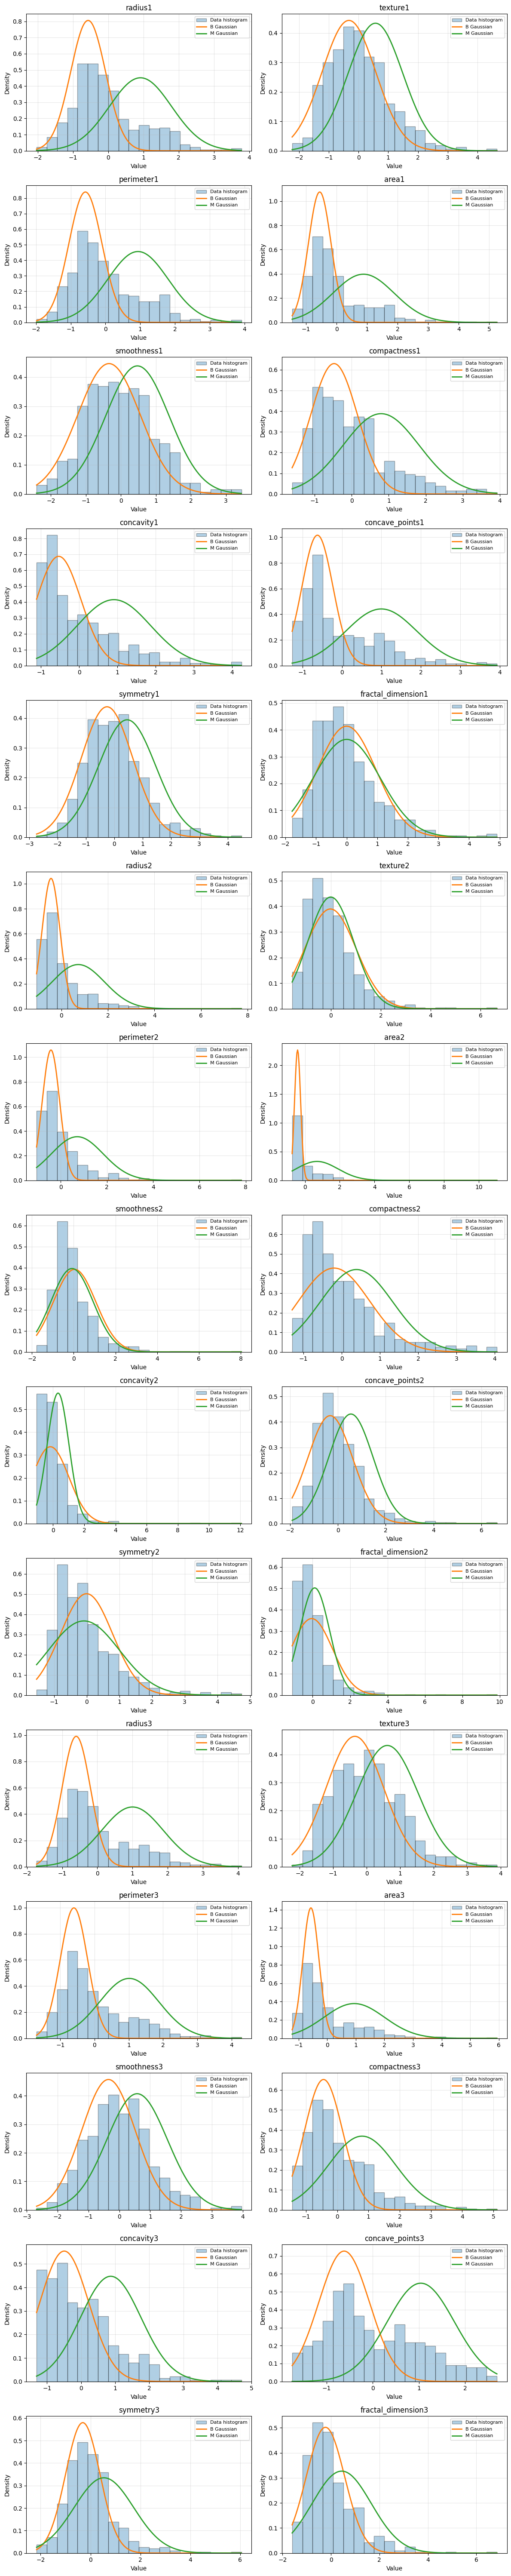

In [24]:
import matplotlib.pyplot as plt

# Plot class-conditional Gaussian fits and empirical distribution for all features in a grid
n_features = train.n_features
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

y_train_1d = np.asarray(y_train).ravel()

for i, feature_name in enumerate(train.feature_names):
    feature_values = x_train[:, i]
    ax = axes[i]

    # empirical distribution (all training samples)
    ax.hist(feature_values, bins=20, density=True, alpha=0.35, edgecolor="black", label="Data histogram")

    # class-conditional Gaussian curves
    x = np.linspace(feature_values.min(), feature_values.max(), 300)
    for cls in model.classes:
        mean, std = model.gaussians[cls][i]
        gaussian_pdf = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)
        ax.plot(x, gaussian_pdf, linewidth=2, label=f"{cls} Gaussian")

    ax.set_title(feature_name)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Hide any unused subplots
for j in range(n_features, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## Predictions

Accuracy: 0.9474

Per-class metrics:
Class | Precision | Recall | F1-score | Support
----------------------------------------------------
    B |     0.971 |  0.944 |    0.958 |      72
    M |     0.909 |  0.952 |    0.930 |      42


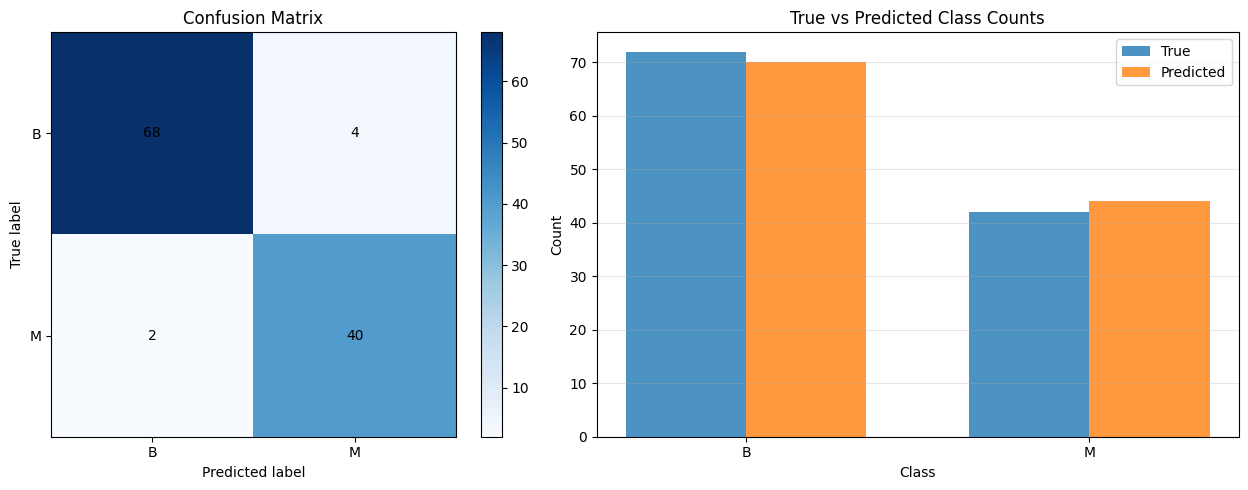

In [25]:
# Generate predictions
y_pred = model.predict(x_test)

# Ensure labels are 1D (handles shapes like (n,) and (n, 1))
y_true = np.asarray(y_test).ravel()
y_pred = np.asarray(y_pred).ravel()

# -----------------------------
# Evaluation metrics (NumPy only)
# -----------------------------
classes = np.unique(np.concatenate([y_true, y_pred]))
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

conf_matrix = np.zeros((len(classes), len(classes)), dtype=int)
for true_label, pred_label in zip(y_true, y_pred):
    conf_matrix[class_to_idx[true_label], class_to_idx[pred_label]] += 1

accuracy = np.mean(y_pred == y_true)
print(f"Accuracy: {accuracy:.4f}")

print("\nPer-class metrics:")
print("Class | Precision | Recall | F1-score | Support")
print("-" * 52)
for i, cls in enumerate(classes):
    tp = conf_matrix[i, i]
    fp = conf_matrix[:, i].sum() - tp
    fn = conf_matrix[i, :].sum() - tp
    support = conf_matrix[i, :].sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    print(f"{cls:>5} | {precision:>9.3f} | {recall:>6.3f} | {f1:>8.3f} | {support:>7}")

# -----------------------------
# Visualization
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Confusion matrix heatmap
im = axes[0].imshow(conf_matrix, cmap="Blues")
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
axes[0].set_xticks(np.arange(len(classes)))
axes[0].set_yticks(np.arange(len(classes)))
axes[0].set_xticklabels(classes)
axes[0].set_yticklabels(classes)

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        axes[0].text(j, i, conf_matrix[i, j], ha="center", va="center", color="black")

fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# 2) True vs Predicted class distribution
true_counts = np.array([(y_true == cls).sum() for cls in classes])
pred_counts = np.array([(y_pred == cls).sum() for cls in classes])
x_pos = np.arange(len(classes))
width = 0.35

axes[1].bar(x_pos - width / 2, true_counts, width, label="True", alpha=0.8)
axes[1].bar(x_pos + width / 2, pred_counts, width, label="Predicted", alpha=0.8)
axes[1].set_title("True vs Predicted Class Counts")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(classes)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()